# plotting results

Plotting the permuation and sobol results from multiple models and showing the most important variable


In [55]:
import intake
import xarray as xr
from matplotlib import pyplot as plt
import numpy as np

from glob import glob
import pathlib
import traceback
from datetime import datetime



In [56]:
# parameters
dirstore="sa_2020"
#dirstore='sa_2050'
#dirstore='sa_2090'

In [57]:
dname=dirstore[0:-1]
dirsave='/g/data/xv83/rxm599/acs/hazard_fire/paper2/figs/'
outf1='/scratch/xv83/rxm599/'+dirstore+'/*_sa.nc'
ds = xr.open_mfdataset(outf1,
    combine="nested",   # treat files as ordered sequence
    concat_dim="model"  # new dimension name
)
print(outf1)
outf2='/scratch/xv83/rxm599/'+dirstore+'/*_pa.nc'
dt = xr.open_mfdataset(outf2,
    combine="nested",   # treat files as ordered sequence
    concat_dim="model"  # new dimension name
)
print(outf2)
dt

/scratch/xv83/rxm599/sa_2020/*_sa.nc
/scratch/xv83/rxm599/sa_2020/*_pa.nc


<xarray.Dataset>
Dimensions:   (lat: 691, lon: 861, nvar: 4, stat: 3, model: 22)
Coordinates:
    abbrevs   <U3 'AUS'
  * lat       (lat) float64 -44.5 -44.45 -44.4 -44.35 ... -10.1 -10.05 -10.0
  * lon       (lon) float64 112.0 112.0 112.1 112.2 ... 154.8 154.9 154.9 155.0
    names     <U9 'Australia'
    quantile  float64 0.95
    region    int64 0
  * nvar      (nvar) <U4 'DI' 'Tmax' 'Hmin' 'Wmax'
  * stat      (stat) <U4 'mean' 'std' 'diag'
Dimensions without coordinates: model
Data variables:
    mean      (model, lat, lon, stat, nvar) float64 dask.array<chunksize=(1, 691, 861, 3, 4), meta=np.ndarray>

In [58]:
def plot_4(SM1,id,ss,tit,fname='tmp.png'):
    cb='plasma'
    lev = np.linspace(0, .5, 11)
    plt.figure(figsize=(8,10))
    plt.subplot(2,2,1); ax=SM1.sel(sa_1=id[0],stat=ss).plot(levels=lev,cmap=cb,extend='max')
    colorbar = ax.colorbar
    colorbar.set_label('Fraction')
    plt.title(id[0])
    
    plt.subplot(2,2,2); ax=SM1.sel(sa_1=id[1],stat=ss).plot(levels=lev,cmap=cb,extend='max')
    colorbar = ax.colorbar
    colorbar.set_label('Fraction')
    plt.title(id[1])
    
    plt.subplot(2,2,3); ax=SM1.sel(sa_1=id[2],stat=ss).plot(levels=lev,cmap=cb,extend='max')
    colorbar = ax.colorbar
    colorbar.set_label('Fraction')
    plt.title(id[2])
    
    plt.subplot(2,2,4); ax=SM1.sel(sa_1=id[3],stat=ss).plot(levels=lev,cmap=cb,extend='max')
    colorbar = ax.colorbar
    colorbar.set_label('Fraction')
    plt.title(id[3])
    
# Add global title
    plt.suptitle(tit)
# Adjust layout so titles don’t overlap
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    return
    
def plot_4a(SM1,id,tit,fname='tmp.png'):
    cb='plasma'
    lev = np.linspace(0, .5, 11)
    plt.figure(figsize=(8,9))
    plt.subplot(2,2,1); ax=SM1.sel(nvar=id[0]).plot(levels=lev,cmap=cb,extend='max')
    colorbar = ax.colorbar
    colorbar.set_label('Fraction')
    plt.title(id[0])
    
    plt.subplot(2,2,2); ax=SM1.sel(nvar=id[1]).plot(levels=lev,cmap=cb,extend='max')
    colorbar = ax.colorbar
    colorbar.set_label('Fraction')
    plt.title(id[1])
    
    plt.subplot(2,2,3); ax=SM1.sel(nvar=id[2]).plot(levels=lev,cmap=cb,extend='max')
    colorbar = ax.colorbar
    colorbar.set_label('Fraction')
    plt.title(id[2])
    
    plt.subplot(2,2,4); ax=SM1.sel(nvar=id[3]).plot(levels=lev,cmap=cb,extend='max')
    colorbar = ax.colorbar
    colorbar.set_label('Fraction')
    plt.title(id[3])
# Add global title
    plt.suptitle(tit)
# Adjust layout so titles don’t overlap
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    return

In [59]:
SA=ds.SA
SM=SA.mean(dim='model')
SV=SA.std(dim='model')
Rerr=SV/SM 
SM1 = SM.where(Rerr < .5)
print(dirsave,dirstore)

/g/data/xv83/rxm599/acs/hazard_fire/paper2/figs/ sa_2020


/g/data/xv83/rxm599/acs/hazard_fire/paper2/figs/sobol_0_sa_2020.png


/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


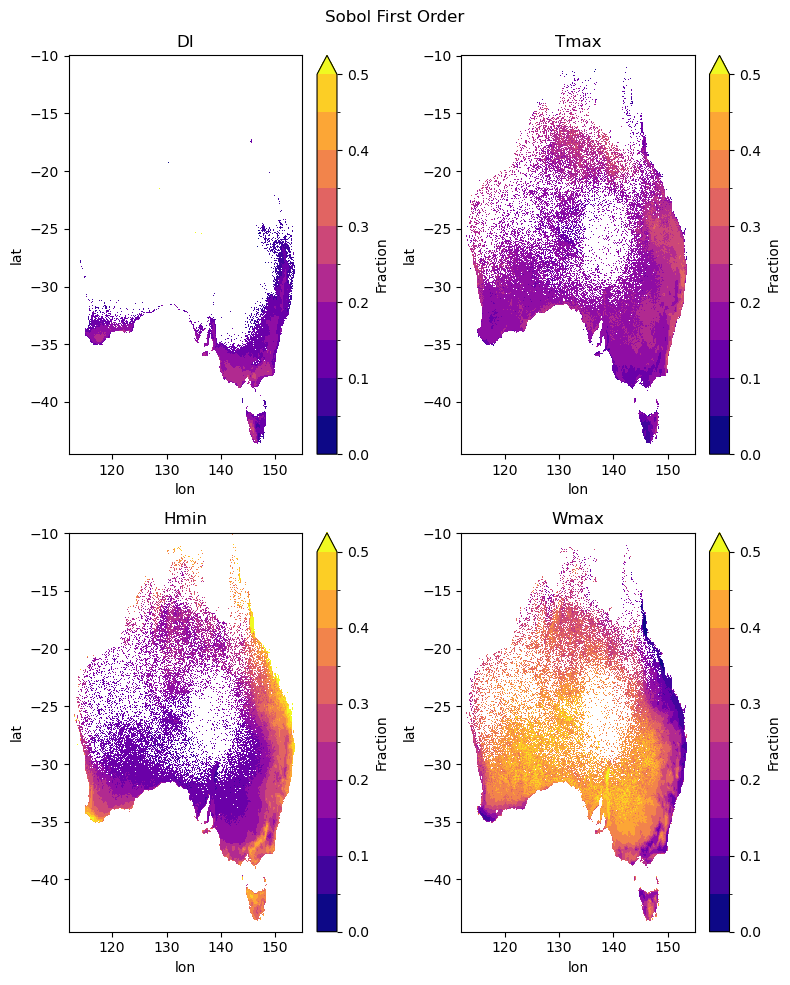

In [60]:
id=['DI','Tmax','Hmin','Wmax']
fname=dirsave+'sobol_0_'+dirstore+'.png'
print(fname)
titl='Sobol First Order'
plot_4(SM1,id,0,titl,fname)
#lev = np.linspace(0, .5, 21)

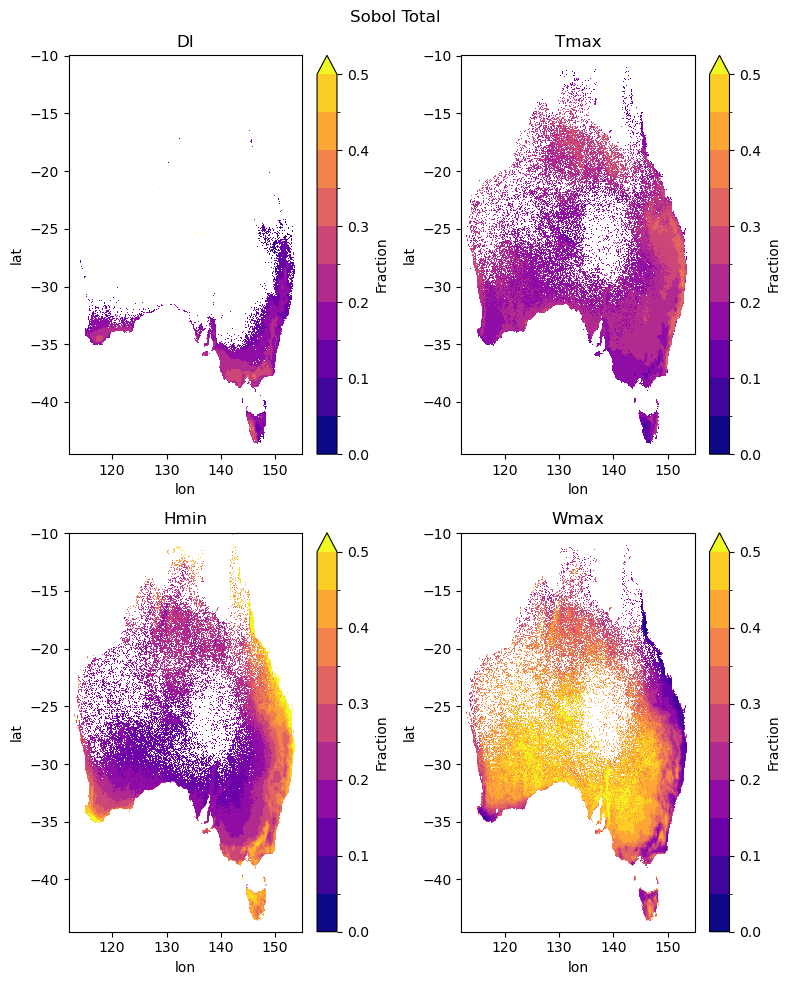

In [61]:
titl='Sobol Total'
plot_4(SM1,id,1,titl,dirsave+'sobol_t_'+dirstore+'.png')

In [62]:
PAr=dt['mean']  # old file
PAr=dt['mean'].sel(stat='mean')
PA = PAr/ PAr.sum(dim='nvar')
PM=PA.mean(dim='model')
PV=PA.std(dim='model')
Rerr=PV/PM 
PM1 = PM.where(Rerr < .5).load()

/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


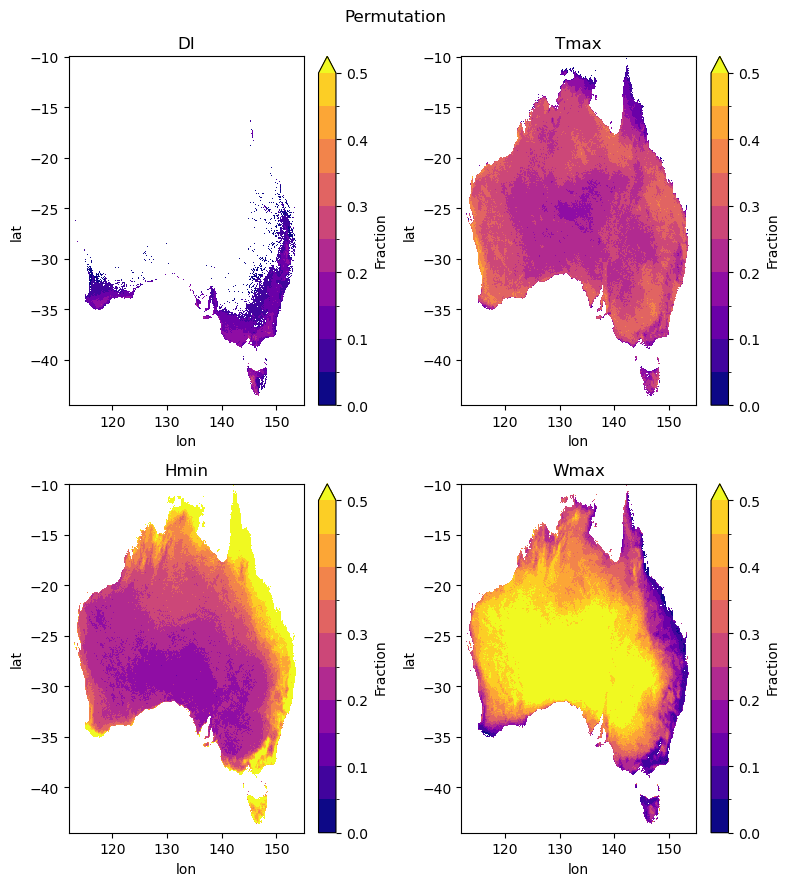

In [63]:
titl='Permutation'
plot_4a(PM1,id,titl,dirsave+'perm_'+dirstore+'.png')

/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


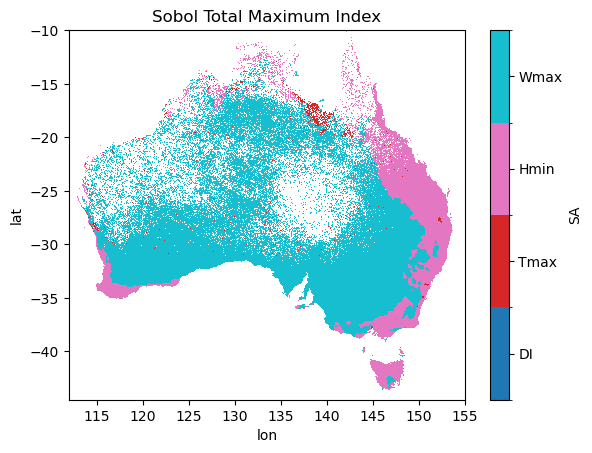

In [64]:

def plot_max_index(SM1,ndim,tit,fname='tmp.png'):
    pmax = SM1.fillna(-np.inf).argmax(dim=ndim)
# Set max_index to NaN where all values were NaN
    all_nan_mask = SM1.isnull().all(dim=ndim)
    pmax = pmax.where(~all_nan_mask)
    nvar=SM1[ndim].values
    lp1=len(nvar)+1
    ax=pmax.plot(cmap="tab10",levels=np.arange(lp1)-.5)
# Replace ticks with variable names
    nvar=SM1[ndim].values
    colorbar = ax.colorbar
    ticks = np.arange(len(nvar))  # 0,1,2,3
    colorbar.set_ticks(ticks)
    colorbar.set_ticklabels(nvar)
    ax=plt.title(tit)
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    
# Compute Index with the largest value
SM2=SM1.sel(stat=1)
nvar=SM1.sa_1.values
ndim='sa_1'
tit='Sobol Total Maximum Index'
fname=dirsave+'sobol_t_max_index_'+dirstore+'.png'
plot_max_index(SM2,ndim,tit,fname)

/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


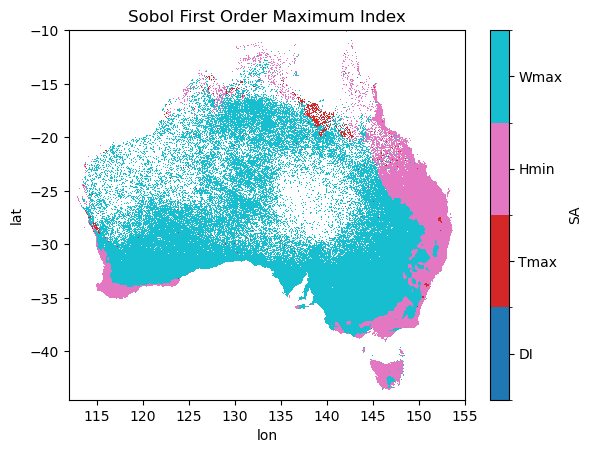

In [65]:
SM2=SM1.sel(stat=0)
ndim='sa_1'
tit='Sobol First Order Maximum Index'
fname=dirsave+'sobol_1_max_index_'+dirstore+'.png'
plot_max_index(SM2,ndim,tit,fname)


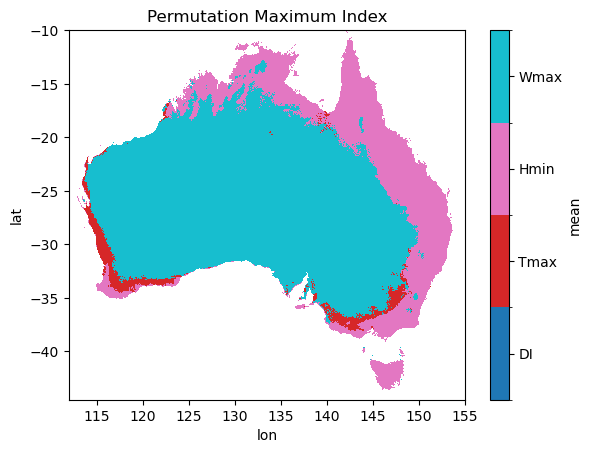

In [66]:
# Compute Index with the largest value
tit='Permutation Maximum Index'
fname=dirsave+'perm_tmax_index_'+dirstore+'.png'
ndim='nvar'

plot_max_index(PM1,ndim,tit,fname)